<a href="https://colab.research.google.com/github/Gabriel-Freitas-S/previsao-turnover-funcionarios/blob/main/notebooks/previsao_turnover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsao de Rotatividade de Funcionarios (Turnover)
## Machine Learning - Classificacao Binaria

**Problema:** Prever se um funcionario tem alta probabilidade de deixar a empresa.

**Dataset:** IBM HR Analytics Employee Attrition & Performance (1470 registros, 35 atributos)

**Algoritmos:** Regressao Logistica vs Random Forest

**Metrica principal:** F1-Score (dado o desbalanceamento das classes)

## 1. Configuracao do Ambiente

In [12]:
import os
import requests

# Caminho do arquivo
DATA_PATH = 'HR_Employee_Attrition.csv'

# URL fornecida pelo usuário do seu próprio repositório
url = 'https://raw.githubusercontent.com/Gabriel-Freitas-S/previsao-turnover-funcionarios/refs/heads/main/data/HR_Employee_Attrition.csv'

if not os.path.exists(DATA_PATH):
    print(f'Baixando dataset de: {url}')
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()
        with open(DATA_PATH, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print('Download concluído com sucesso!')
    except Exception as e:
        print(f'Erro ao baixar o dataset: {e}')
else:
    print('O dataset já existe localmente.')

print(f'Pronto para uso: {DATA_PATH}')

Baixando dataset de: https://raw.githubusercontent.com/Gabriel-Freitas-S/previsao-turnover-funcionarios/refs/heads/main/data/HR_Employee_Attrition.csv
Download concluído com sucesso!
Pronto para uso: HR_Employee_Attrition.csv


## 2. Importacao das Bibliotecas

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)

## 3. Carregamento e Exploracao dos Dados

In [14]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Colunas: {df.columns.tolist()}')
print(f'Valores nulos: {df.isnull().sum().sum()}')

attrition_dist = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
print(f'Distribuicao Attrition:')
print(attrition_dist)
print(attrition_pct.round(2))

Shape: (1470, 35)
Colunas: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Valores nulos: 0
Distribuicao Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


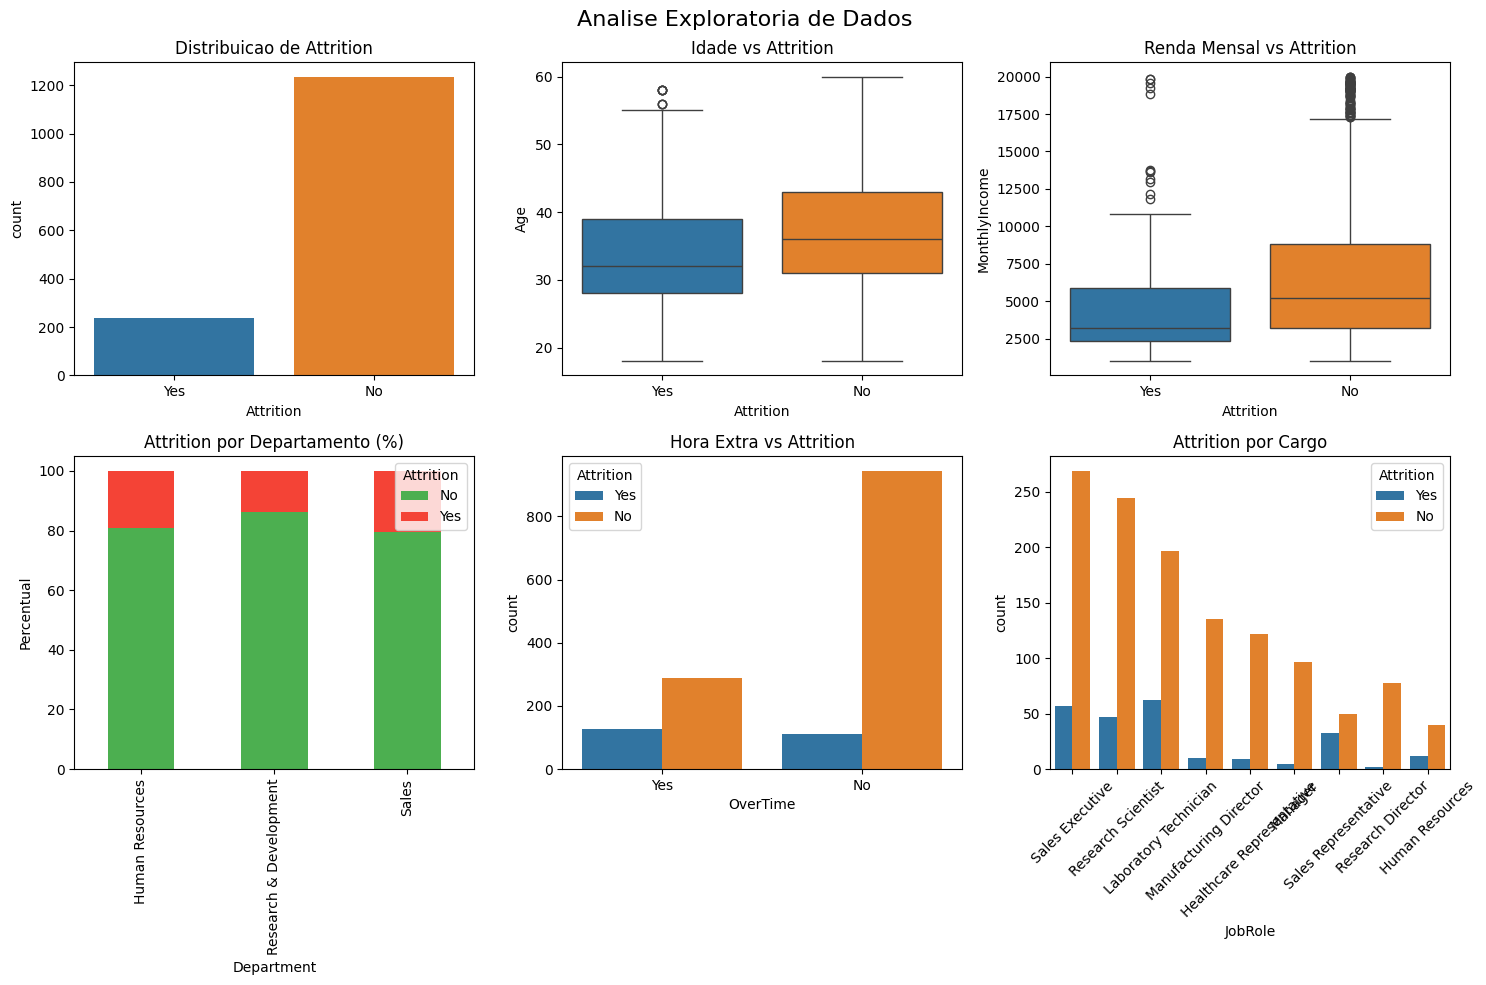

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Analise Exploratoria de Dados', fontsize=16)

sns.countplot(data=df, x='Attrition', hue='Attrition', ax=axes[0,0], legend=False)
axes[0,0].set_title('Distribuicao de Attrition')

sns.boxplot(data=df, x='Attrition', y='Age', hue='Attrition', ax=axes[0,1], legend=False)
axes[0,1].set_title('Idade vs Attrition')

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', ax=axes[0,2], legend=False)
axes[0,2].set_title('Renda Mensal vs Attrition')

att_by_dept = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
att_by_dept.plot(kind='bar', stacked=True, ax=axes[1,0], color=['#4CAF50', '#F44336'])
axes[1,0].set_title('Attrition por Departamento (%)')
axes[1,0].set_ylabel('Percentual')

sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[1,1])
axes[1,1].set_title('Hora Extra vs Attrition')

sns.countplot(data=df, x='JobRole', hue='Attrition', ax=axes[1,2])
axes[1,2].set_title('Attrition por Cargo')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Principais Insights da EDA

- 83,88% dos funcionarios permanecem (No) vs 16,12% sairam (Yes)
- Funcionarios mais jovens apresentam maior propensao a saida
- Renda mensal mais baixa correlaciona com maior turnover
- Horas extras (OverTime) aumentam significativamente o risco
- Departamento de Vendas (Sales) tem maior taxa de attrition

## 4. Pre-processamento dos Dados

In [16]:
X = df.drop(columns=['Attrition', 'EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])
y = df['Attrition'].map({'Yes': 1, 'No': 0})

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print(f'Features numericas: {len(numeric_features)}')
print(f'Features categoricas: {len(categorical_features)}')

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')

Features numericas: 23
Features categoricas: 7
Treino: 1176 amostras
Teste:  294 amostras


## 5. Treinamento com GridSearchCV

In [17]:
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ))
])

param_lr = {'classifier__C': [0.01, 0.1, 1, 10, 100]}

gs_lr = GridSearchCV(
    pipe_lr, param_lr,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1', n_jobs=-1, verbose=1
)
gs_lr.fit(X_train, y_train)
print(f'Melhores params (LR): {gs_lr.best_params_}')
print(f'Melhor F1 (CV): {gs_lr.best_score_:.4f}')

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhores params (LR): {'classifier__C': 0.1}
Melhor F1 (CV): 0.4962


In [18]:
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', random_state=42
    ))
])

param_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

gs_rf = GridSearchCV(
    pipe_rf, param_rf,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1', n_jobs=-1, verbose=1
)
gs_rf.fit(X_train, y_train)
print(f'Melhores params (RF): {gs_rf.best_params_}')
print(f'Melhor F1 (CV): {gs_rf.best_score_:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Melhores params (RF): {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Melhor F1 (CV): 0.4750


## 6. Avaliacao no Conjunto de Teste

In [19]:
results = {}

for name, gs in [('Regressao Logistica', gs_lr), ('Random Forest', gs_rf)]:
    y_pred = gs.predict(X_test)
    y_proba = gs.predict_proba(X_test)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
    }

    print(f'\n=== {name} ===')
    print(f'Acuracia: {results[name]["accuracy"]:.4f}')
    print(f'Precisao: {results[name]["precision"]:.4f}')
    print(f'Recall:   {results[name]["recall"]:.4f}')
    print(f'F1:       {results[name]["f1_score"]:.4f}')
    print(f'ROC-AUC:  {results[name]["roc_auc"]:.4f}')

    cm = results[name]['confusion_matrix']
    print(f'Matriz de Confusao:')
    print(cm)


=== Regressao Logistica ===
Acuracia: 0.7585
Precisao: 0.3636
Recall:   0.6809
F1:       0.4741
ROC-AUC:  0.8023
Matriz de Confusao:
[[191  56]
 [ 15  32]]

=== Random Forest ===
Acuracia: 0.8231
Precisao: 0.4468
Recall:   0.4468
F1:       0.4468
ROC-AUC:  0.7494
Matriz de Confusao:
[[221  26]
 [ 26  21]]


## 7. Comparacao dos Resultados

In [20]:
comparison = pd.DataFrame(results).T
display(comparison[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']].round(4))

,accuracy,precision,recall,f1_score,roc_auc
Regressao Logistica,0.758503,0.363636,0.680851,0.474074,0.802309
Random Forest,0.823129,0.446809,0.446809,0.446809,0.749419


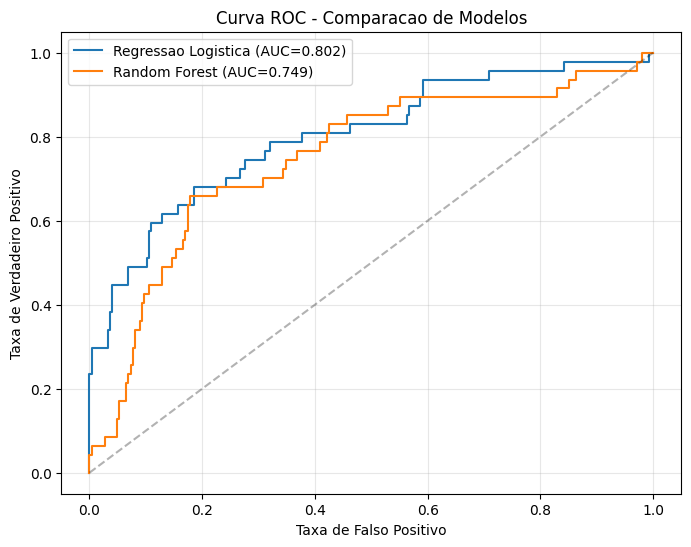

In [21]:
plt.figure(figsize=(8, 6))
for name, gs in [('Regressao Logistica', gs_lr), ('Random Forest', gs_rf)]:
    fpr, tpr, _ = roc_curve(y_test, gs.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, gs.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC - Comparacao de Modelos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Conclusao

- A **Regressao Logistica** obteve melhor F1-Score e Recall, priorizando a deteccao de saidas
- O **Random Forest** teve maior Acuracia, mas isso e enganoso devido ao desbalanceamento
- `class_weight='balanced'` foi crucial para melhorar a deteccao da classe positiva

### Possiveis Melhorias

- Testar SMOTE como alternativa ao class_weight='balanced'
- Explorar XGBoost, SVM ou Redes Neurais
- Coletar mais dados para melhorar a generalizacao